In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('BRFSS2023.csv')

In [3]:
df.shape

(433323, 350)

In [4]:
df.columns.tolist()

['_state',
 'fmonth',
 'idate',
 'imonth',
 'iday',
 'iyear',
 'dispcode',
 'seqno',
 '_psu',
 'ctelenm1',
 'pvtresd1',
 'colghous',
 'statere1',
 'celphon1',
 'ladult1',
 'numadult',
 'respslc1',
 'landsex2',
 'lndsxbrt',
 'safetime',
 'ctelnum1',
 'cellfon5',
 'cadult1',
 'cellsex2',
 'celsxbrt',
 'pvtresd3',
 'cclghous',
 'cstate1',
 'landline',
 'hhadult',
 'sexvar',
 'genhlth',
 'physhlth',
 'menthlth',
 'poorhlth',
 'primins1',
 'persdoc3',
 'medcost1',
 'checkup1',
 'exerany2',
 'exract12',
 'exeroft1',
 'exerhmm1',
 'exract22',
 'exeroft2',
 'exerhmm2',
 'strength',
 'bphigh6',
 'bpmeds1',
 'cholchk3',
 'toldhi3',
 'cholmed3',
 'cvdinfr4',
 'cvdcrhd4',
 'cvdstrk3',
 'asthma3',
 'asthnow',
 'chcscnc1',
 'chcocnc1',
 'chccopd3',
 'addepev3',
 'chckdny2',
 'havarth4',
 'diabete4',
 'diabage4',
 'marital',
 'educa',
 'renthom1',
 'numhhol4',
 'numphon4',
 'cpdemo1c',
 'veteran3',
 'employ1',
 'children',
 'income3',
 'pregnant',
 'weight2',
 'height3',
 'deaf',
 'blind',
 'decide',

In [5]:
columns_to_keep = [
    'genhlth',    # gen health
    'physhlth',   # physical health
    'menthlth',   # mental health
    'poorhlth',   # health quality
    'smoke100',   # Smoked 100 cigarettes
    'alcday4',    # Alcohol days
    'exerany2',   # Exercise
    '_bmi5',      # BMI * 100
    'diabete4',   # Diabetes
    'bpmeds1',    # Blood pressure meds
    'asthma3',    # Asthma
    '_age_g',     # Age group
    'educa',      # Education
    'income3',    # Income level
    '_sex',       # Gender
    'colncncr'    # Colon Cancer
]
df = df[columns_to_keep]

In [21]:
df.head(10)

,genhlth,physhlth,menthlth,poorhlth,smoke100,alcday4,exerany2,_bmi5,diabete4,bpmeds1,asthma3,_age_g,educa,income3,_sex,colncncr
0,2.0,88.0,88.0,NaN,2.0,888.0,2.0,3047.0,1.0,1.0,2.0,6,5.0,<NA>,2,NaN
1,2.0,88.0,88.0,NaN,2.0,888.0,1.0,2856.0,3.0,2.0,2.0,6,5.0,<NA>,2,NaN
2,4.0,6.0,2.0,1.0,1.0,888.0,1.0,2231.0,3.0,1.0,1.0,6,4.0,2.0,2,NaN
3,2.0,2.0,88.0,88.0,2.0,888.0,1.0,2744.0,3.0,NaN,2.0,6,5.0,<NA>,2,NaN
4,4.0,88.0,88.0,NaN,2.0,202.0,1.0,2585.0,1.0,1.0,2.0,6,5.0,<NA>,2,NaN
5,3.0,2.0,3.0,88.0,2.0,205.0,1.0,3018.0,3.0,1.0,2.0,5,5.0,<NA>,2,NaN
6,4.0,8.0,<NA>,88.0,1.0,888.0,2.0,2441.0,3.0,NaN,2.0,6,4.0,6.0,1,NaN
7,4.0,1.0,88.0,1.0,2.0,888.0,2.0,2727.0,1.0,1.0,2.0,6,5.0,<NA>,2,NaN
8,3.0,5.0,88.0,88.0,2.0,888.0,2.0,3347.0,3.0,1.0,2.0,6,5.0,6.0,2,NaN
9,3.0,88.0,88.0,NaN,1.0,888.0,1.0,2296.0,1.0,1.0,2.0,6,4.0,<NA>,1,NaN


In [22]:
df.isnull().sum()

genhlth       1262
physhlth     19861
menthlth     16075
poorhlth    193066
smoke100     22568
alcday4      29940
exerany2      1251
_bmi5        40535
diabete4       984
bpmeds1     257603
asthma3       1701
_age_g           0
educa         2325
income3     196803
_sex             0
colncncr    423043
dtype: int64

In [24]:
df = df.copy()

cat_cols = ['genhlth','smoke100','alcday4','exerany2','diabete4',
            'asthma3','educa','income3','bpmeds1','colncncr','_sex','_age_g']

num_cols = ['physhlth','menthlth','poorhlth','_bmi5']

# categorical value filled with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].infer_objects(copy=False)

# numeric value filled with median
for col in num_cols:
    df[col] = df[col].astype(float)
    df[col] = df[col].fillna(df[col].median())
    df[col] = df[col].infer_objects(copy=False)

df_clean = df

In [25]:
df.isnull().sum()

genhlth     0
physhlth    0
menthlth    0
poorhlth    0
smoke100    0
alcday4     0
exerany2    0
_bmi5       0
diabete4    0
bpmeds1     0
asthma3     0
_age_g      0
educa       0
income3     0
_sex        0
colncncr    0
dtype: int64

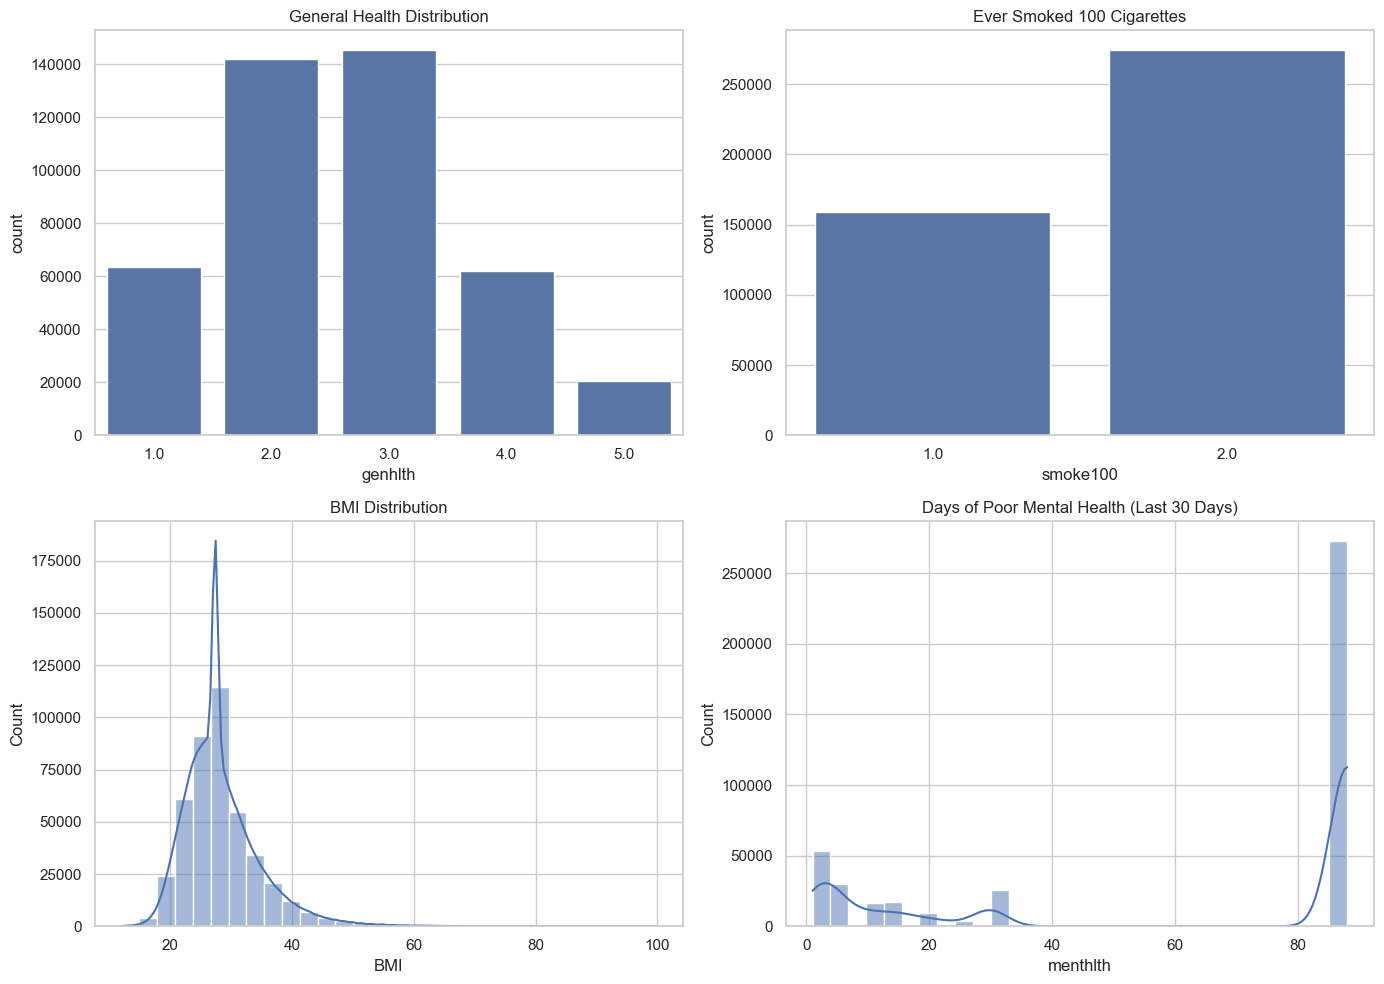

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.figure(figsize=(14, 10))

# Convert BMI to real scale
df_clean['BMI'] = df_clean['_bmi5'] / 100

# Plot distributions
plt.subplot(2, 2, 1)
sns.countplot(x='genhlth', data=df_clean)
plt.title('General Health Distribution')

plt.subplot(2, 2, 2)
sns.countplot(x='smoke100', data=df_clean)
plt.title('Ever Smoked 100 Cigarettes')

plt.subplot(2, 2, 3)
sns.histplot(df_clean['BMI'], kde=True, bins=30)
plt.title('BMI Distribution')

plt.subplot(2, 2, 4)
sns.histplot(df_clean['menthlth'], kde=True, bins=30)
plt.title('Days of Poor Mental Health (Last 30 Days)')

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [37]:
y = df_clean[['_bmi5', 'physhlth', 'menthlth', 'poorhlth']]
X = df_clean.drop(columns=['_bmi5', 'physhlth', 'menthlth', 'poorhlth'])
X = pd.get_dummies(X, drop_first=True)

In [41]:
X_train, X_test, y_train, y_test, = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [46]:
print(df_clean.columns.tolist())

['genhlth', 'physhlth', 'menthlth', 'poorhlth', 'smoke100', 'alcday4', 'exerany2', '_bmi5', 'diabete4', 'bpmeds1', 'asthma3', '_age_g', 'educa', 'income3', '_sex', 'colncncr', 'BMI']


In [48]:
y = df_clean[['genhlth', 'physhlth', 'menthlth', 'poorhlth', 'smoke100', 'alcday4', 'exerany2', '_bmi5', 'diabete4', 'bpmeds1', 'asthma3', '_age_g', 'educa', 'income3', '_sex', 'colncncr', 'BMI']]
print(y.shape)

(433323, 17)


In [49]:
print("df_clean shape:", df_clean.shape)

print("X shape:", X.shape)

print("y shape:", y.shape)

df_clean shape: (433323, 17)
X shape: (433323, 13)
y shape: (433323, 17)


In [56]:
target_cols = ['genhlth', 'physhlth', 'menthlth', 'poorhlth', 'smoke100', 'alcday4', 'exerany2', '_bmi5', 'diabete4', 'bpmeds1', 'asthma3', '_age_g', '_sex', 'colncncr', 'BMI']

In [57]:
X = df_clean.drop(columns=target_cols)
y = df_clean[target_cols]

In [58]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (433323, 2)
y shape: (433323, 15)


In [59]:
X = pd.get_dummies(X, drop_first=True)

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate each target separately
for i, col in enumerate(y.columns):
    mse = mean_squared_error(y_test[col], y_pred[:, i])
    r2 = r2_score(y_test[col], y_pred[:, i])
    print(f"{col}: MSE={mse:.2f}, R²={r2:.2f}")


genhlth: MSE=0.99, R²=0.10
physhlth: MSE=1378.86, R²=0.01
menthlth: MSE=1406.42, R²=0.00
poorhlth: MSE=1130.65, R²=0.01
smoke100: MSE=0.23, R²=0.03
alcday4: MSE=122126.21, R²=0.06
exerany2: MSE=0.17, R²=0.07
_bmi5: MSE=386452.60, R²=0.01
diabete4: MSE=0.51, R²=0.01
bpmeds1: MSE=0.07, R²=0.00
asthma3: MSE=0.13, R²=0.00
_age_g: MSE=2.61, R²=0.01
_sex: MSE=0.25, R²=0.01
colncncr: MSE=0.01, R²=0.00
BMI: MSE=38.65, R²=0.01


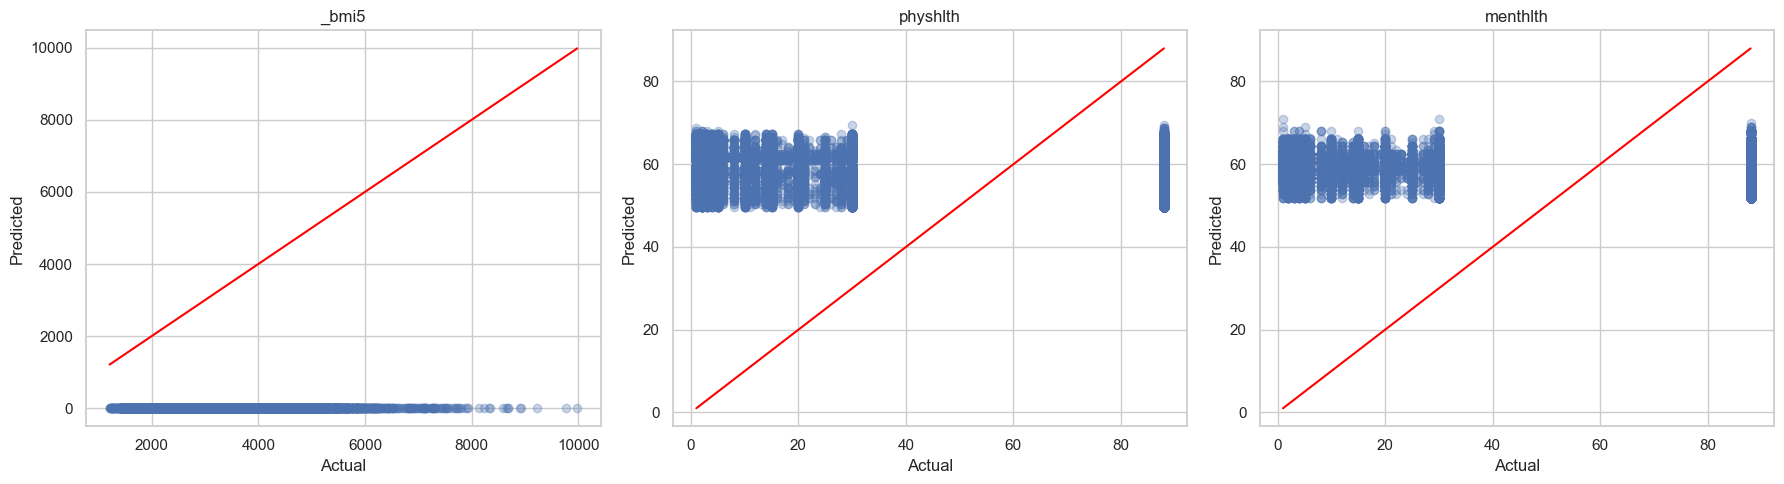

In [61]:
import matplotlib.pyplot as plt

targets = ['_bmi5', 'physhlth', 'menthlth']
plt.figure(figsize=(18,5))

for i, target in enumerate(targets):
    plt.subplot(1, len(targets), i+1)
    plt.scatter(y_test[target], y_pred[:, i], alpha=0.3)
    plt.plot([y_test[target].min(), y_test[target].max()],
             [y_test[target].min(), y_test[target].max()],
             color='red')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(target)

plt.tight_layout()
plt.show()